# Assessment Task 1
## Section 1(a): SVM Classifier with LBP 

### Dataset Preparation
The following steps applies the 'split-folders' module to correctly extract and randomly organise the classes presented under the 'student_25349642' folder into Training, Testing and Validation datasets whilst ensuring that the folder structue is maintained. From here, the dataset is loaded and reshaped to fit the LBP Classifier.

### 1. Extract files and Set-up Train-Test-Validation Splits

In [1]:
!unzip student_25349642.zip

Archive:  student_25349642.zip
replace student_25349642/+/+_100242.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


In [2]:
!pip install opencv-python-headless

  Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl.metadata (19 kB)
  Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached opencv_python_headless-4.13.0.92-cp37-abi3-manylinux_2_28_x86_64.whl (60.4 MB)
Using cached numpy-2.4.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4━━━━━ 0/2 [numpy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python-headless]v-python-headless]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not in

In [3]:
!pip install split-folders

  Using cached split_folders-0.6.1-py3-none-any.whl.metadata (11 kB)
Using cached split_folders-0.6.1-py3-none-any.whl (13 kB)


In [4]:
import splitfolders

splitfolders.ratio("student_25349642", output="output", seed=1337, ratio=(.8, .1, .1),
                   group_prefix=None, group=None, formats=(".jpg", ".jpeg", ".png"), move=False, shuffle=True)

Copying files: 5000 files [00:04, 1162.00 files/s]


### 2. Import all required modules

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import feature # This pacakge is used for LBP feature extraction
from sklearn import svm # This pacakge is used for svm classification
from sklearn import metrics
%matplotlib inline
import cv2
import seaborn as sns # This pacakge is used for better visualization of data (e.g confusion matrix)
import os
from sklearn.model_selection import train_test_split
from skimage.feature import local_binary_pattern
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

### 3. Data Exploration and Model Loading

In [6]:
labelName = ['+', 'beta', 'cos', 'leq', 'M', 'N', 'R', 'rightarrow', 'S', 'z']

def load_dataset(path):

    data = []
    labels = []

    for label in labelName:
        class_path = os.path.join(path, label)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (28, 28))

            data.append(img.flatten())
            labels.append(labelName.index(label))
            
    return np.array(data), np.array(labels)

In [7]:
X_train, y_train = load_dataset('./output/train')
X_test, y_test = load_dataset('./output/test')
X_val, y_val = load_dataset('./output/val')

In [8]:
print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(X_val))

(4000, 784)
(500, 784)
(500, 784)


In [9]:
X_train=X_train.reshape(-1,28,28)
X_test=X_test.reshape(-1,28,28)
X_val=X_val.reshape(-1,28,28)

# print the size of the result reshaped train and test data splits

print("Train dataset after reshaping:{}".format(np.shape(X_train)))
print("Test dataset after reshaping :{}".format(np.shape(X_test)))
print("Val dataset after reshaping :{}".format(np.shape(X_val)))

Train dataset after reshaping:(4000, 28, 28)
Test dataset after reshaping :(500, 28, 28)
Val dataset after reshaping :(500, 28, 28)


+
cos
rightarrow
rightarrow


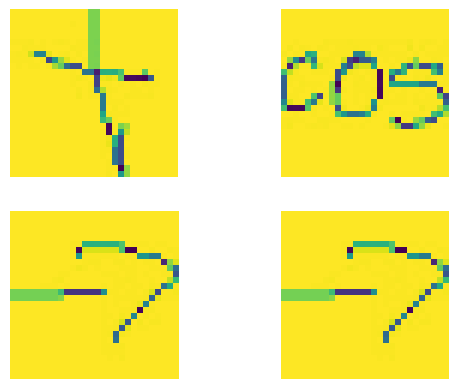

In [10]:
img_index = 10
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.axis('off')
ax1.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,2)
ax2.axis('off')
img_index = 1000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,3)
ax2.axis('off')
img_index = 3000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

ax2 = fig.add_subplot(2,2,4)
ax2.axis('off')
img_index = 3000
ax2.imshow(X_train[img_index])
print(labelName[y_train[img_index]])

In [11]:
class LocalBinaryPatterns:
	def __init__(self, numPoints, radius):
		# store the number of points and radius
		self.numPoints = numPoints
		self.radius = radius

	def LBPfeatures(self, image, eps=1e-7):
		# compute the Local Binary Pattern representation
		# of the image, and then use the LBP representation
		# to build the histogram of patterns
		lbp = feature.local_binary_pattern(image, self.numPoints,
			self.radius, method="uniform")
    # Form the histogram
		(hist, _) = np.histogram(lbp.ravel(),
			bins=np.arange(0, self.numPoints + 3),
			range=(0, self.numPoints + 2))

		# normalize the histogram
		hist = hist.astype("float")
		hist /= (hist.sum() + eps)

		# return the histogram of Local Binary Patterns
		return hist

In [12]:
# Create an object of LocalBinaryPatterns class and initial the parameters.
desc = LocalBinaryPatterns(24, 8)
data_train_lbp = []
labels_train_lbp = []

## WRITE YOUR CODE HERE (~ 3 lines)
# loop over the training images
for img_index in range(len(X_train)):
	# load the train image, and extract LBP features
	image = (X_train[img_index])
	hist = desc.LBPfeatures(image)
## END YOUR CODE HERE

	# extract the label from the image path, then update the
	# label and data lists
	labels_train_lbp.append(y_train[img_index])
	data_train_lbp.append(hist)

### Model Training
The following section trains a SVM Classifier on the LBP features extracted during the Dataset Preparation

### 4. Training SVM Classifier

In [13]:
# train a SVM clasifier on the training data
# Initialize the SVM model
# Use rbf Kernel, c = 100 and randon_state=42

## WRITE YOUR CODE HERE (~ 2 lines)
model_lbp = svm.SVC(kernel='rbf', C = 100, random_state = 42, gamma='scale')
# Start training the SVM classifier
model_lbp.fit(data_train_lbp, labels_train_lbp)
## END YOUR CODE HERE

data_val_lbp = []
labels_val_lbp = []

for img_index in range(len(X_val)):
    image = (X_val[img_index])
    hist = desc.LBPfeatures(image)

    labels_val_lbp.append(y_val[img_index])
    data_val_lbp.append(hist)

val_accuracy = model_lbp.score(data_val_lbp, labels_val_lbp)
print("Validation Accuracy:", val_accuracy)

print(np.shape(data_train_lbp))
print(np.shape(labels_train_lbp))

Validation Accuracy: 0.608
(4000, 26)
(4000,)


In [14]:
# Check the training accuray
print("Train set Accuracy: {:.2f}".format(model_lbp.score(data_train_lbp, labels_train_lbp)))

# Expected training set Accuracy 0.60

Train set Accuracy: 0.60


In [15]:
prediction_lbp=[]
predict_label_lbp=[]
# Exract LBP features for each test sample and classify it with the trained SVM classifier

## WRITE YOUR CODE HERE (~ 2 lines)
for im_index in range(len(X_test)):
  imag = X_test[im_index]

  # Extract LBP feature
  histo = desc.LBPfeatures(imag)
  # Perform classification, Hint: use model.predict()
  prediction = model_lbp.predict(histo.reshape(1, -1))[0]
## END YOUR CODE HERE

  # Store the classfication result
  prediction_lbp.append(prediction)
  predict_label_lbp.append(y_test[im_index])

In [16]:
accuracy = metrics.accuracy_score(y_test, prediction_lbp)
print("Accuracy on test dataset:", accuracy)

Accuracy on test dataset: 0.614


### Model Analysis
The following section visualises the results of the SVM + LBP classifier using a Confusion Matrix along with the evaluation matricies Precision, Recall, F1-Score and Accuracy 

### 5. Confusion Matrix Visualisation

[[41  0  0  3  1  0  0  5  0  0]
 [ 0 39  1  2  3  0  3  0  1  1]
 [ 0  3 44  1  1  0  0  0  1  0]
 [ 2  1  0 33  4  3  0  5  1  1]
 [ 0  7  3  6 18  6  0  4  1  5]
 [ 1  4  1  5  3 26  0  3  4  3]
 [ 1  5  1  3  1  1 29  6  0  3]
 [ 6  1  0  6  3  0  1 31  1  1]
 [ 1  3  0  2  4  2  1  3 29  5]
 [ 3  3  4  3  6  6  0  0  8 17]]


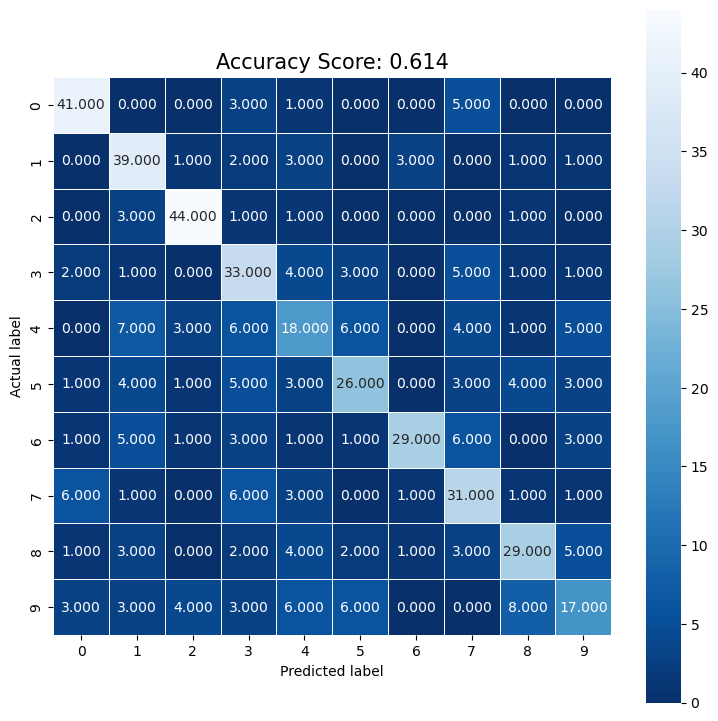

In [17]:
# plot the confusion matrix
cm_lbp  = metrics.confusion_matrix(y_test, prediction_lbp)
print(cm_lbp)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm_lbp, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [18]:
# Display some classification result on test samples
images = []
pred_label = []
true_label = []

# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
  # classify the clothing
  histog = desc.LBPfeatures(X_test[i])
  prediction = model_lbp.predict(histog.reshape(1, -1))[0]
  label = labelName[prediction]
  orig_label = labelName[y_test[i]]
  image = X_test[i]
  image = cv2.merge([image] * 3)
  image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)

  # cv2.putText(image, f"Predicted Label: {label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 0), 2)
  # cv2.putText(image, f"True Label: {orig_label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 0, 0), 2)
    
  images.append(image)
  pred_label.append(label)
  true_label.append(orig_label)

### 6. Sample Model Results

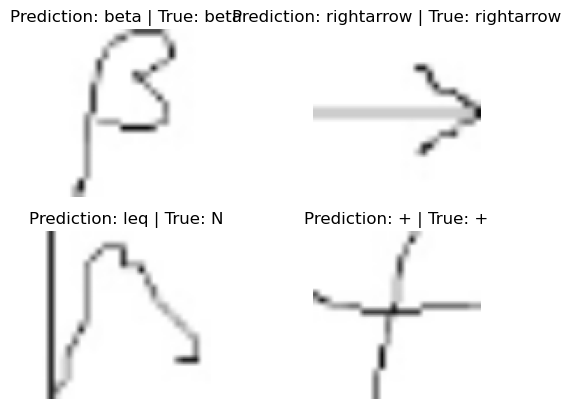

In [19]:
## Display the classification results
#Plot the image and the predicted labels
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(images[0])
ax1.set_title(f"Prediction: {pred_label[0]} | True: {true_label[0]}")
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(images[1])
ax2.set_title(f"Prediction: {pred_label[1]} | True: {true_label[1]}")
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(images[2])
ax3.set_title(f"Prediction: {pred_label[2]} | True: {true_label[2]}")
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(images[3])
ax4.set_title(f"Prediction: {pred_label[3]} | True: {true_label[3]}")
ax4.axis("off")
plt.show()

### 7. Evaluation Matricies: Precision, Recall, F1-Score and Accuracy

In [20]:
print("Test Accuracy: ", accuracy_score(y_test, prediction_lbp))

print(classification_report(y_test, prediction_lbp, target_names=labelName))

Test Accuracy:  0.614
              precision    recall  f1-score   support

           +       0.75      0.82      0.78        50
        beta       0.59      0.78      0.67        50
         cos       0.81      0.88      0.85        50
         leq       0.52      0.66      0.58        50
           M       0.41      0.36      0.38        50
           N       0.59      0.52      0.55        50
           R       0.85      0.58      0.69        50
  rightarrow       0.54      0.62      0.58        50
           S       0.63      0.58      0.60        50
           z       0.47      0.34      0.40        50

    accuracy                           0.61       500
   macro avg       0.62      0.61      0.61       500
weighted avg       0.62      0.61      0.61       500



# Assessment Task 1
## Section 1(b): SVM Classifier with HOG 

### Dataset Preparation
As the dataset has been already loaded into the workspace, the initial Train-Test-Validation splitting is not required to be done again. Additionally, the imports are not required to be re-listed here. Hence we can directly begin with building the Histogram-Oriented Gradient (HOG) Model.

### Model Training
The following section trains a SVM Classifier on the HOG features extracted during the Dataset Preparation

In [21]:
# initialize the data matrix and labels
print("Extracting features from training dataset...")
data_train_hog = []
labels_train_hog = []

# loop over the training images
for img_index in range(len(X_train)):
  # load the image, and extract HOG features it
  ## WRITE YOUR CODE HERE ## (~ 4 lines)
  image = (X_train[img_index])

  # Hint: use orientation =9, pixel_per_cell=(10,10), cells_per_block=2,2,
  # transform_sqrt=True and block_norm="L2-Hys"
  #
  H = feature.hog(image, orientations=9, 
                  pixels_per_cell=(10,10), 
                  cells_per_block=(2,2), 
                  transform_sqrt=True, 
                  block_norm='L2-Hys') # Complete the code

  # update the data and labels
  data_train_hog.append(H) # Complete the code
  labels_train_hog.append(y_train[img_index]) # Complete the code
## END YOUR CODE HERE ##
print(np.shape(data_train_hog))
print(np.shape(labels_train_hog))

Extracting features from training dataset...
(4000, 36)
(4000,)


### 1. Training SVM Classifier

In [22]:
model_hog = svm.SVC(kernel='rbf', C = 100, random_state=42, gamma='scale')
model_hog.fit(data_train_hog, labels_train_hog)

,C,100
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [23]:
data_val_hog = []
labels_val_hog = []

for img_index in range(len(X_val)):
    image = X_val[img_index]

    H = feature.hog(image,
                    orientations=9,
                    pixels_per_cell=(10,10),
                    cells_per_block=(2,2),
                    transform_sqrt=True,
                    block_norm='L2-Hys')

    data_val_hog.append(H)
    labels_val_hog.append(y_val[img_index])

val_accuracy_hog = model_hog.score(data_val_hog, labels_val_hog)
print("Validation Accuracy:", val_accuracy_hog)

Validation Accuracy: 0.844


In [24]:
# Check the training accuray
print("Train set Accuracy: {:.2f}".format(model_hog.score(data_train_hog,labels_train_hog)))

# Expected training set Accuracy 0.60

Train set Accuracy: 1.00


In [25]:
predictions_hog = []

for img_ind in range(len(X_test)):

    img = X_test[img_ind]

    H = feature.hog(img,
                    orientations=9,
                    pixels_per_cell=(10,10),
                    cells_per_block=(2,2),
                    transform_sqrt=True,
                    block_norm='L2-Hys')

    pred = model_hog.predict(H.reshape(1,-1))[0]

    predictions_hog.append(pred)

In [26]:
accuracy_hog = metrics.accuracy_score(y_test, predictions_hog)
print("Accuracy on test dataset:", accuracy_hog)

Accuracy on test dataset: 0.876


### Model Analysis
The following section visualises the results of the SVM + HOG classifier using a Confusion Matrix along with the evaluation matricies Precision, Recall, F1-Score and Accuracy 

### 2. Confusion Matrix Visualisation

[[49  0  0  0  0  1  0  0  0  0]
 [ 0 46  0  0  0  1  2  0  0  1]
 [ 0  0 45  0  4  0  0  0  0  1]
 [ 0  0  0 48  0  0  0  0  2  0]
 [ 0  0  2  0 42  6  0  0  0  0]
 [ 1  1  0  0  5 37  6  0  0  0]
 [ 1  2  1  1  4  8 32  0  1  0]
 [ 1  0  0  0  0  1  0 48  0  0]
 [ 0  0  0  0  1  1  0  0 48  0]
 [ 2  1  1  0  2  1  0  0  0 43]]


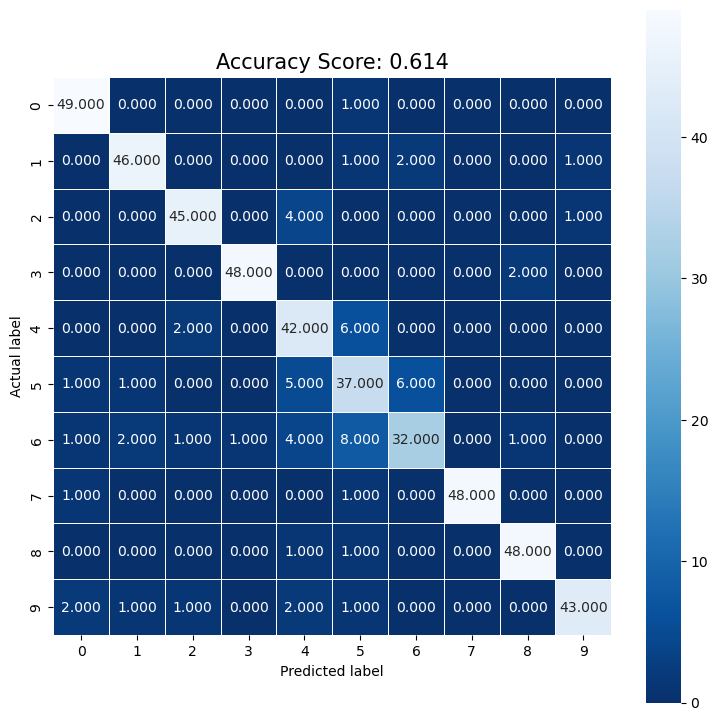

In [27]:
# plot the confusion matrix
cm_hog  = metrics.confusion_matrix(y_test, predictions_hog)
print(cm_hog)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm_hog, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [28]:
# Display some classification result on test samples
images = []
pred_label = []
true_label = []

# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
  # classify the clothing
  H1 = feature.hog(X_test[i],
                   orientations=9,
                   pixels_per_cell=(10,10),
                   cells_per_block=(2,2),
                   transform_sqrt=True,
                   block_norm="L2-Hys")
  prediction = model_hog.predict(H1.reshape(1, -1))[0]
  label = labelName[prediction]
  orig_label = labelName[y_test[i]]
  image = X_test[i]
  image = cv2.merge([image] * 3)
  image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)

  # cv2.putText(image, f"Predicted Label: {label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 0), 2)
  # cv2.putText(image, f"True Label: {orig_label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 0, 0), 2)
    
  images.append(image)
  pred_label.append(label)
  true_label.append(orig_label)

In [29]:
np.shape(images[1])

(96, 96, 3)

### 3. Sample Model Results

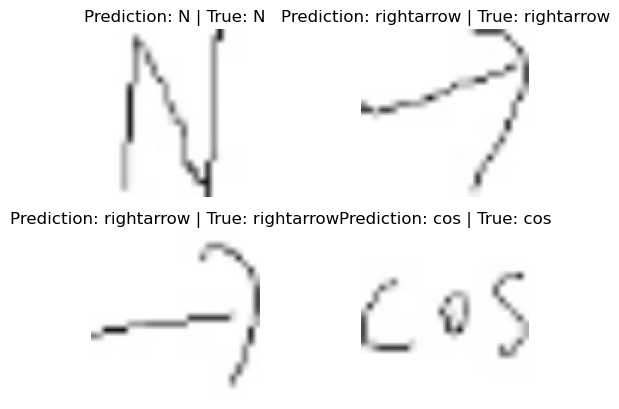

In [30]:
## Display the classification results
#Plot the image and the predicted labels
fig1 = plt.figure()
ax1 = fig1.add_subplot(2,2,1)
ax1.imshow(images[0])
ax1.set_title(f"Prediction: {pred_label[0]} | True: {true_label[0]}")
ax1.axis("off")
ax2 = fig1.add_subplot(2,2,2)
ax2.imshow(images[1])
ax2.set_title(f"Prediction: {pred_label[1]} | True: {true_label[1]}")
ax2.axis("off")
ax3 = fig1.add_subplot(2,2,3)
ax3.imshow(images[2])
ax3.set_title(f"Prediction: {pred_label[2]} | True: {true_label[2]}")
ax3.axis("off")
ax4 = fig1.add_subplot(2,2,4)
ax4.imshow(images[3])
ax4.set_title(f"Prediction: {pred_label[3]} | True: {true_label[3]}")
ax4.axis("off")
plt.show()

### 4. Evaluation Matricies: Precision, Recall, F1-Score and Accuracy

In [31]:
print("Test Accuracy: ", accuracy_score(y_test, predictions_hog))

print(classification_report(y_test, predictions_hog, target_names=labelName))

Test Accuracy:  0.876
              precision    recall  f1-score   support

           +       0.91      0.98      0.94        50
        beta       0.92      0.92      0.92        50
         cos       0.92      0.90      0.91        50
         leq       0.98      0.96      0.97        50
           M       0.72      0.84      0.78        50
           N       0.66      0.74      0.70        50
           R       0.80      0.64      0.71        50
  rightarrow       1.00      0.96      0.98        50
           S       0.94      0.96      0.95        50
           z       0.96      0.86      0.91        50

    accuracy                           0.88       500
   macro avg       0.88      0.88      0.88       500
weighted avg       0.88      0.88      0.88       500



# Assessment Task 1
## Section 1(c): SVM Classifier with Raw Pixels (rawpxl) 

### Dataset Preparation
For computing the Raw Pixel Value, it is important to first normalise the dataset. Additionally, when loading into the SVM the raw pixels must be flattened into a [28x28, 1] vector. Consequently, like computing the first model, the training process cannot be skipped and is hence included here.

### 1. Data Exploration and Model Loading

In [32]:
labelName = ['+', 'beta', 'cos', 'leq', 'M', 'N', 'R', 'rightarrow', 'S', 'z']

def load_dataset(path):

    data = []
    labels = []

    for label in labelName:
        class_path = os.path.join(path, label)

        for img_name in os.listdir(class_path):
            img_path = os.path.join(class_path, img_name)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = cv2.resize(img, (28, 28))

            img = img / 255.0
            data.append(img.flatten())
            labels.append(labelName.index(label))
            
    return np.array(data), np.array(labels)

In [33]:
X_train, y_train = load_dataset('./output/train')
X_test, y_test = load_dataset('./output/test')
X_val, y_val = load_dataset('./output/val')

In [34]:
print(np.shape(X_train))
print(np.shape(X_test))
print(np.shape(X_val))

(4000, 784)
(500, 784)
(500, 784)


### Model Training
The following section trains a SVM Classifier on the normalised raw pixels extracted during the Dataset Preparation

### 2. Training SVM Classifier

In [35]:
model_rawpxl = svm.SVC(kernel='rbf', C = 100, random_state=42, gamma='scale')
model_rawpxl.fit(X_train, y_train)

,C,100
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [36]:
predictions = model_rawpxl.predict(X_test)

In [37]:
val_accuracy = model_rawpxl.score(X_val, y_val)
print("Validation Accuracy:", val_accuracy)

Validation Accuracy: 0.924


In [38]:
# Check the training accuray
print("Train set Accuracy: {:.2f}".format(model_rawpxl.score(X_train,y_train)))

# Expected training set Accuracy 0.60

Train set Accuracy: 1.00


In [39]:
accuracy = metrics.accuracy_score(y_test, predictions)
print("Accuracy on test dataset:",accuracy)

Accuracy on test dataset: 0.93


### Model Analysis
The following section visualises the results of the SVM + Raw Pixel classifier using a Confusion Matrix along with the evaluation matricies Precision, Recall, F1-Score and Accuracy 

### 3. Confusion Matrix Visualisation

[[48  0  0  0  1  1  0  0  0  0]
 [ 0 50  0  0  0  0  0  0  0  0]
 [ 0  0 46  0  4  0  0  0  0  0]
 [ 0  0  0 48  0  1  0  0  1  0]
 [ 0  0  0  0 44  6  0  0  0  0]
 [ 1  0  0  0  5 43  0  0  0  1]
 [ 0  2  0  0  0  4 44  0  0  0]
 [ 1  0  0  0  0  0  0 49  0  0]
 [ 0  0  0  1  0  2  1  0 46  0]
 [ 1  0  0  0  2  0  0  0  0 47]]


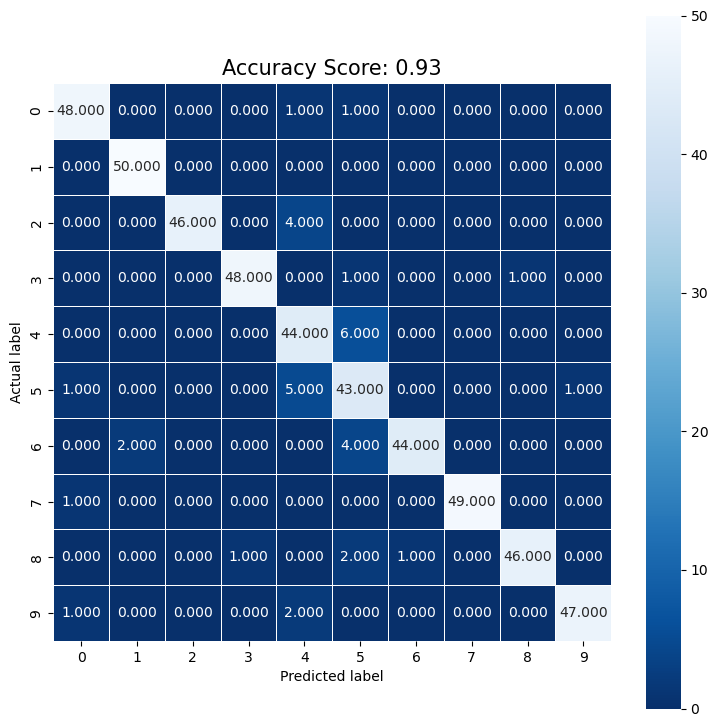

In [40]:
# plot the confusion matrix
cm_rawpxl  = metrics.confusion_matrix(y_test, predictions)
print(cm_rawpxl)

# Plot confusion matrix using seaborn library
plt.figure(figsize=(9,9))
sns.heatmap(cm_rawpxl, annot=True, fmt=".3f", linewidths=.5, square = True, cmap = 'Blues_r');
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
all_sample_title = 'Accuracy Score: {0}'.format(accuracy)
plt.title(all_sample_title, size = 15);

In [42]:
# Display some classification result on test samples
images_rawpxl = []
pred_label_rawpxl = []
true_label_rawpxl = []

# randomly select a few testing fashion items
for i in np.random.choice(np.arange(0, len(y_test)), size=(16,)):
  # classify the clothing
  prediction = model_rawpxl.predict(X_test[i].reshape(1, -1))[0]
  label = labelName[prediction]
  orig_label = labelName[y_test[i]]
  image = X_test[i].reshape(28, 28)

  if image.max() <= 1.0:
      image = image * 255.0
  image = image.astype("uint8")
  image = cv2.merge([image] * 3)
  image = cv2.resize(image, (96, 96), interpolation=cv2.INTER_LINEAR)

  # cv2.putText(image, f"Predicted Label: {label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (0, 255, 0), 2)
  # cv2.putText(image, f"True Label: {orig_label}", (5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.50, (255, 0, 0), 2)
    
  images_rawpxl.append(image)
  pred_label_rawpxl.append(label)
  true_label_rawpxl.append(orig_label)

In [43]:
np.shape(images[1])

(96, 96, 3)

### 4. Sample Model Results

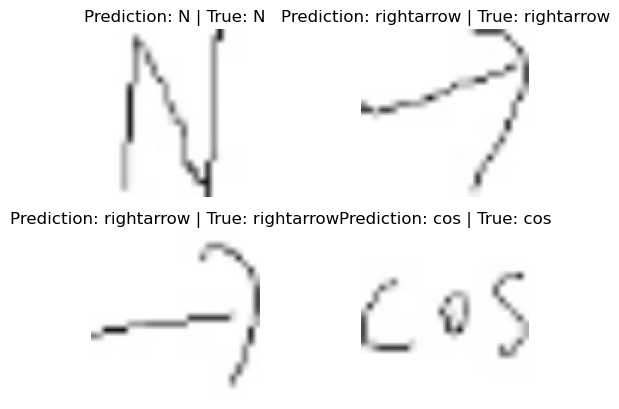

In [44]:
## Display the classification results
#Plot the image and the predicted labels
fig = plt.figure()
ax1 = fig.add_subplot(2,2,1)
ax1.imshow(images[0])
ax1.set_title(f"Prediction: {pred_label[0]} | True: {true_label[0]}")
ax1.axis("off")
ax2 = fig.add_subplot(2,2,2)
ax2.imshow(images[1])
ax2.set_title(f"Prediction: {pred_label[1]} | True: {true_label[1]}")
ax2.axis("off")
ax3 = fig.add_subplot(2,2,3)
ax3.imshow(images[2])
ax3.set_title(f"Prediction: {pred_label[2]} | True: {true_label[2]}")
ax3.axis("off")
ax4 = fig.add_subplot(2,2,4)
ax4.imshow(images[3])
ax4.set_title(f"Prediction: {pred_label[3]} | True: {true_label[3]}")
ax4.axis("off")
plt.show()

### 5. Evaluation Matricies: Precision, Recall, F1-Score and Accuracy

In [45]:
print("Test Accuracy: ", accuracy_score(y_test, predictions))

print(classification_report(y_test, predictions, target_names=labelName))

Test Accuracy:  0.93
              precision    recall  f1-score   support

           +       0.94      0.96      0.95        50
        beta       0.96      1.00      0.98        50
         cos       1.00      0.92      0.96        50
         leq       0.98      0.96      0.97        50
           M       0.79      0.88      0.83        50
           N       0.75      0.86      0.80        50
           R       0.98      0.88      0.93        50
  rightarrow       1.00      0.98      0.99        50
           S       0.98      0.92      0.95        50
           z       0.98      0.94      0.96        50

    accuracy                           0.93       500
   macro avg       0.94      0.93      0.93       500
weighted avg       0.94      0.93      0.93       500

